**Traffic_Volume_Prediction**

In [229]:
import pandas as pd

Reading the data from csv file

In [230]:
data = pd.read_csv('/content/Metro_Interstate_Traffic_Volume .csv')

In [231]:
data.shape

(48204, 9)

In [232]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


By seeing the data, it is pretty much clear that holiday has missing values, to train the model we have to handle those missing values so it understands the data clearly


In [233]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [234]:
data.isna().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [235]:
(data['holiday']).value_counts()

,count
holiday,
Labor Day,7
Christmas Day,6
Thanksgiving Day,6
Martin Luther King Jr Day,6
New Years Day,6
Veterans Day,5
Columbus Day,5
Memorial Day,5
Washingtons Birthday,5


In [236]:
(data['holiday']).isna().sum()

np.int64(48143)

In [237]:
((data['holiday'] == 'None') | (data['holiday'] == 'none')).sum()

np.int64(0)

only holiday column has missing values that  are not numbers as well as the present values are dtype object, to train the model efficiently we create a new column for holiday so that holidays will have value 1 and remaining days 0 for better understanding

In [238]:
data['is_holiday']=data['holiday'].notna().astype(int)

In [239]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
 9   is_holiday           48204 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 3.7+ MB


In [240]:
data["is_holiday"].value_counts()

,count
is_holiday,
0,48143
1,61


**now we extract important features from data["date_time"]  for further plot analysis**

In [241]:
data['date_time']=pd.to_datetime(data['date_time'])

In [242]:
data['hour']=data['date_time'].dt.hour


In [243]:
data['weekdays']=data['date_time'].dt.dayofweek

In [244]:
data['month']=data['date_time'].dt.month

In [245]:
data['is_weekend']=data['weekdays']>=5

In [246]:
data['year']=data['date_time'].dt.year

**Extracting weather and rain features to see if they affect traffic volume or not**

In [247]:
data['rain_1h'].value_counts()

,count
rain_1h,
0.00,44737
0.25,948
0.51,256
1.02,123
0.30,121
...,...
15.75,1
7.13,1
1.16,1


In [248]:
data['heavy_rain']=(data['rain_1h'] > 2).astype(int)

In [249]:
data['is_snowing'] = (data['snow_1h'] > 0).astype(int)
data['is_snowing'].value_counts()

,count
is_snowing,
0,48141
1,63


In [250]:
data['is_raining'] = (
    data['rain_1h'] > 0
).astype(int)

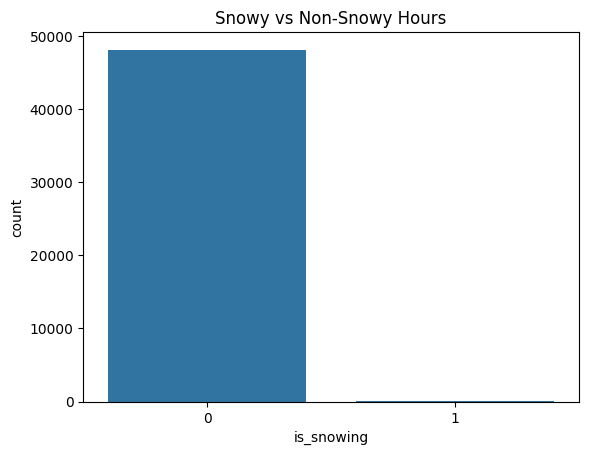

In [251]:
sns.countplot( x='is_snowing', data=data)

plt.title('Snowy vs Non-Snowy Hours')
plt.show()

In [252]:
data['is_raining'].value_counts()

,count
is_raining,
0,44737
1,3467


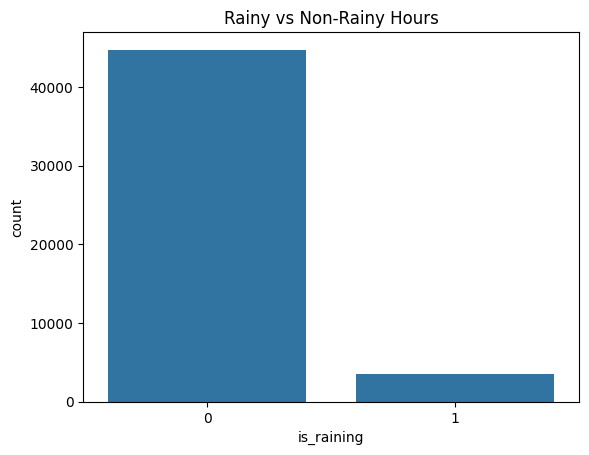

In [253]:
sns.countplot(x='is_raining', data=data)
plt.title('Rainy vs Non-Rainy Hours')
plt.show()

Text(0, 0.5, 'traffic Volume')

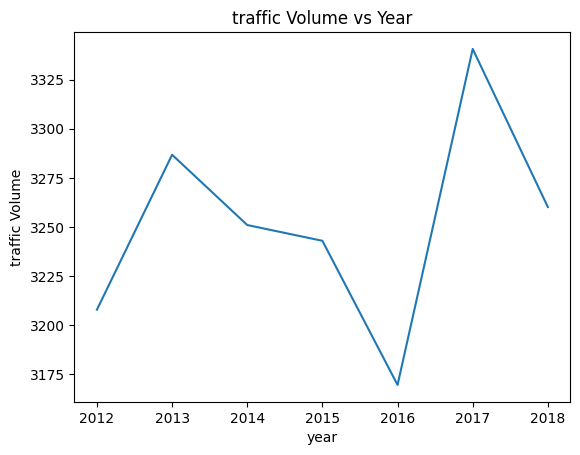

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_yearly_traffic = data.groupby('year')['traffic_volume'].mean()
sns.lineplot(x=avg_yearly_traffic.index, y=avg_yearly_traffic.values)
plt.title("traffic Volume vs Year")
plt.xlabel("year")
plt.ylabel("traffic Volume")

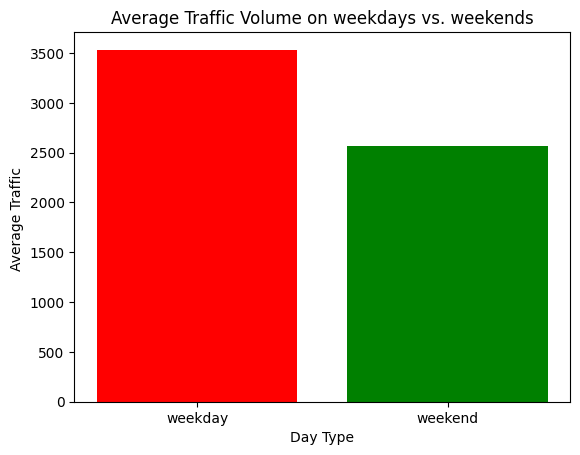

In [255]:
mean_traffic_by_weekend = data.groupby('is_weekend')['traffic_volume'].mean()

plt.bar(['weekday', 'weekend'], height=mean_traffic_by_weekend.values, color=['red', 'green'])
plt.title('Average Traffic Volume on weekdays vs. weekends')
plt.xlabel('Day Type')
plt.ylabel('Average Traffic ')
plt.show()

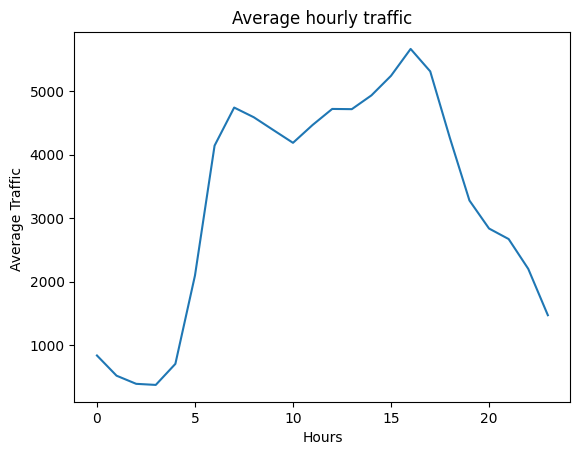

In [256]:
avg_hourly_traffic = data.groupby("hour")['traffic_volume'].mean()
sns.lineplot(x=avg_hourly_traffic.index,y=avg_hourly_traffic.values)
plt.xlabel("Hours")
plt.ylabel("Average Traffic ")
plt.title("Average hourly traffic")
plt.show()

As we can see,traffic starts to increase around 3:00 and gradually increases until around 7:00, then starts to decline and later reaches an all time high at around 4 P.M or 16:00, again declining further ahead

**so rush hours are bewteen 6:00 to 8:00 and 15:00 to  18:00**

In [257]:
data['is_rush_hour'] = ((data['hour'] >= 6) & (data['hour'] <= 8)  | (data['hour'] >= 15) & (data['hour'] <= 18  )).astype(int)

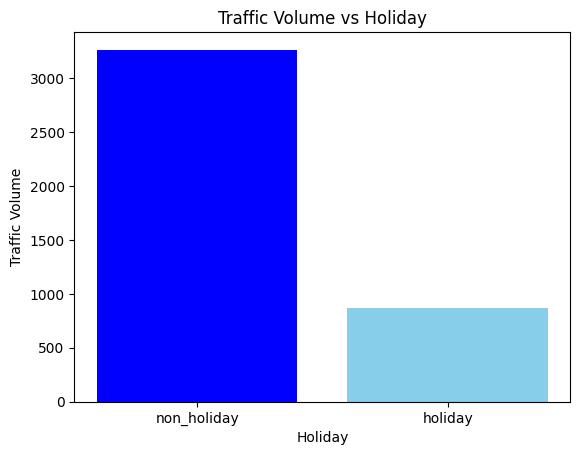

In [258]:
avg_holiday_traffic=data.groupby('is_holiday')['traffic_volume'].mean()

plt.bar(x=["non_holiday",'holiday'], height=avg_holiday_traffic.values, color=['blue','skyblue'])
plt.title("Traffic Volume vs Holiday")
plt.xlabel("Holiday")
plt.ylabel("Traffic Volume")
plt.show()

**so, traffic tends to be  much higher when there is no holiday**

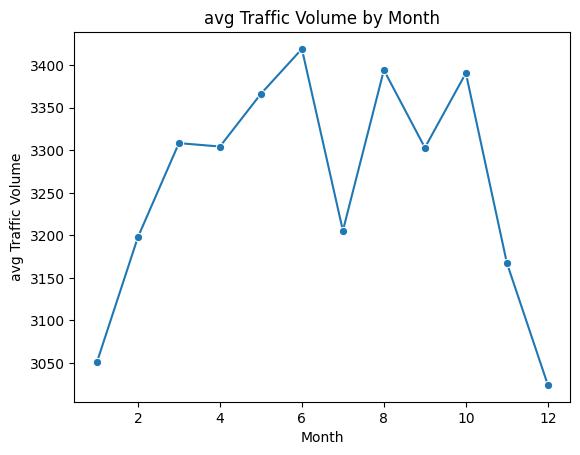

In [259]:
mean_traffic_by_month = data.groupby('month')['traffic_volume'].mean()
sns.lineplot(  x=mean_traffic_by_month.index,  y=mean_traffic_by_month.values,marker='o')
plt.xlabel('Month')
plt.ylabel('avg Traffic Volume')
plt.title('avg Traffic Volume by Month')
plt.show()